# ETL

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
df_errors = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_errors.csv")
df_failures = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_failures.csv")
df_machines = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_machines.csv")
df_maint = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_maint.csv")
df_telemetry = pd.read_csv("https://raw.githubusercontent.com/No-Country-simulation/S08-26-EQUIPO-24/refs/heads/main/data/raw/PdM_telemetry.csv")

In [45]:
df_errors.info()

<class 'pandas.DataFrame'>
RangeIndex: 3919 entries, 0 to 3918
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   datetime   3919 non-null   str  
 1   machineID  3919 non-null   int64
 2   errorID    3919 non-null   str  
dtypes: int64(1), str(2)
memory usage: 187.7 KB


In [46]:
df_errors.head()

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


In [47]:
df_failures.info()

<class 'pandas.DataFrame'>
RangeIndex: 761 entries, 0 to 760
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   datetime   761 non-null    str  
 1   machineID  761 non-null    int64
 2   failure    761 non-null    str  
dtypes: int64(1), str(2)
memory usage: 35.8 KB


In [48]:
df_machines.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   machineID  100 non-null    int64
 1   model      100 non-null    str  
 2   age        100 non-null    int64
dtypes: int64(2), str(1)
memory usage: 3.1 KB


In [49]:
df_maint.info()

<class 'pandas.DataFrame'>
RangeIndex: 3286 entries, 0 to 3285
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   datetime   3286 non-null   str  
 1   machineID  3286 non-null   int64
 2   comp       3286 non-null   str  
dtypes: int64(1), str(2)
memory usage: 154.2 KB


In [50]:
df_telemetry.info()

<class 'pandas.DataFrame'>
RangeIndex: 876100 entries, 0 to 876099
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   datetime   876100 non-null  str    
 1   machineID  876100 non-null  int64  
 2   volt       876100 non-null  float64
 3   rotate     876100 non-null  float64
 4   pressure   876100 non-null  float64
 5   vibration  876100 non-null  float64
dtypes: float64(4), int64(1), str(1)
memory usage: 56.0 MB


In [51]:
df_errors['datetime'] = pd.to_datetime(df_errors['datetime'])

In [52]:
df_failures['datetime'] = pd.to_datetime(df_failures['datetime'])

In [53]:
df_maint['datetime'] = pd.to_datetime(df_maint['datetime'])

In [54]:
df_telemetry['datetime'] = pd.to_datetime(df_telemetry['datetime'])

In [55]:
print(df_errors.duplicated().sum())
print(df_failures.duplicated().sum())
print(df_machines.duplicated().sum())
print(df_maint.duplicated().sum())
print(df_telemetry.duplicated().sum())

0
0
0
0
0


# EDA

In [56]:
df_machines.describe()

,machineID,age
count,100.000000,100.000000
mean,50.500000,11.330000
std,29.011492,5.856974
min,1.000000,0.000000
25%,25.750000,6.750000
50%,50.500000,12.000000
75%,75.250000,16.000000
max,100.000000,20.000000


In [57]:
df_telemetry.describe()

,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-02 17:59:59.999999,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


## ¿Cuántas máquinas hay?

In [58]:
df_machines["machineID"].nunique()

100

In [59]:
df_machines["model"].value_counts()

model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64

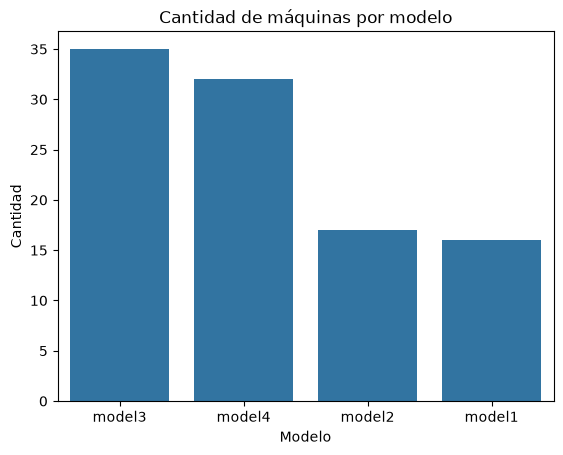

In [60]:
sns.countplot(data=df_machines, x="model")

plt.title("Cantidad de máquinas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Cantidad")

plt.show()

## Edad de las máquinas

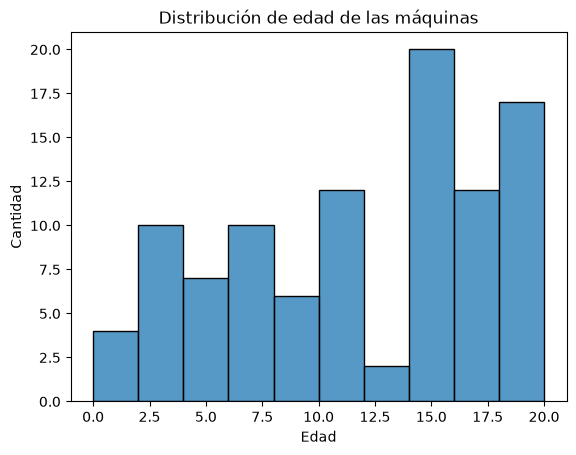

In [61]:
# Graficamos
sns.histplot(data=df_machines, x="age", bins=10)

plt.title("Distribución de edad de las máquinas")
plt.xlabel("Edad")
plt.ylabel("Cantidad")

plt.show()

## Análisis de errores

In [62]:
df_errors.head()

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


In [63]:
len(df_errors)

3919

In [64]:
errors_machine = df_errors["machineID"].value_counts()

errors_machine.head(10)

machineID
22    60
78    54
99    54
15    51
49    51
81    51
63    50
79    50
88    50
17    49
Name: count, dtype: int64

In [65]:
count_type_errors = df_errors.groupby("errorID")["machineID"].count()
print(count_type_errors)

errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: machineID, dtype: int64


In [66]:
error_maquina_combinacion = (
    df_errors.groupby(["machineID", "errorID"])["datetime"].size().reset_index(name="total_errors").sort_values(by="total_errors", ascending=False)
)

print("Combinación de máquina y error con más ocurrencias:")
print(error_maquina_combinacion.head(10))

Combinación de máquina y error con más ocurrencias:
     machineID errorID  total_errors
439         90  error1            20
394         81  error1            19
349         72  error1            18
106         22  error4            18
44          10  error1            17
484         99  error2            17
430         88  error2            17
138         29  error1            16
341         70  error3            16
320         66  error1            16


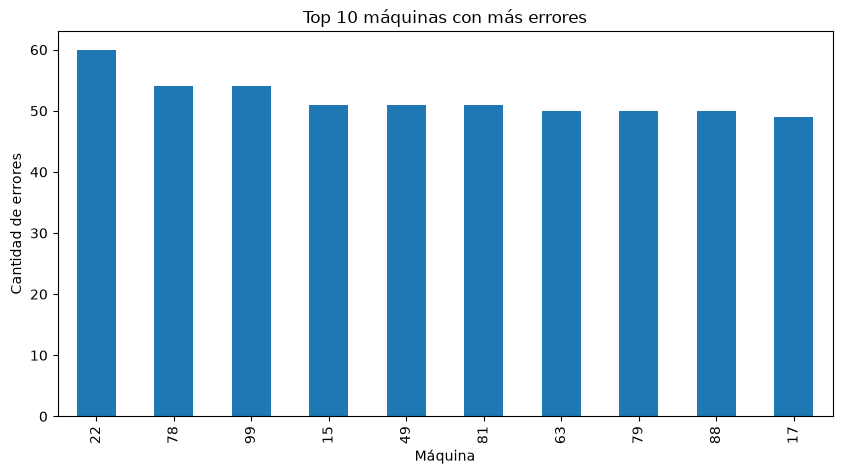

In [67]:
# Graficamos
errors_machine.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 máquinas con más errores")
plt.xlabel("Máquina")
plt.ylabel("Cantidad de errores")

plt.show()

## Análisis de fallas

In [68]:
failures_machine = df_failures["machineID"].value_counts()

failures_machine.head(10)

machineID
99    19
98    16
17    15
22    15
37    14
83    14
13    13
16    13
20    13
71    13
Name: count, dtype: int64

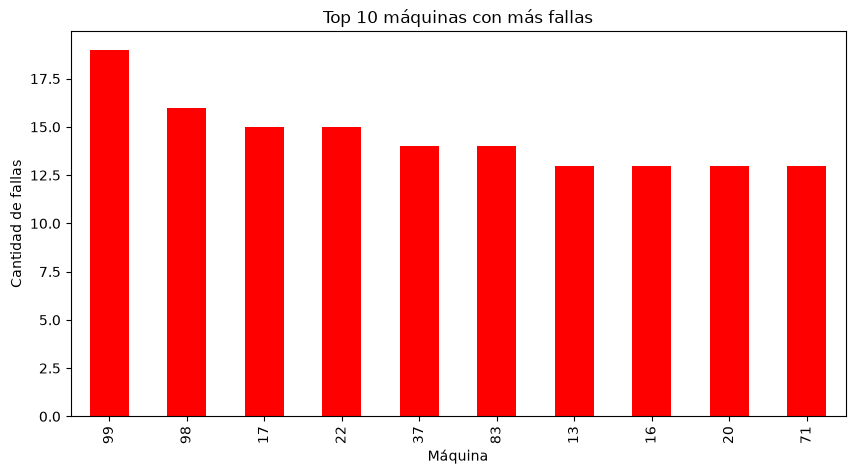

In [69]:
# Graficamos
failures_machine.head(10).plot(kind="bar", figsize=(10,5), color="red")

plt.title("Top 10 máquinas con más fallas")
plt.xlabel("Máquina")
plt.ylabel("Cantidad de fallas")

plt.show()

## Análisis de los tipos de falla

In [70]:
df_failures["failure"].value_counts()

failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

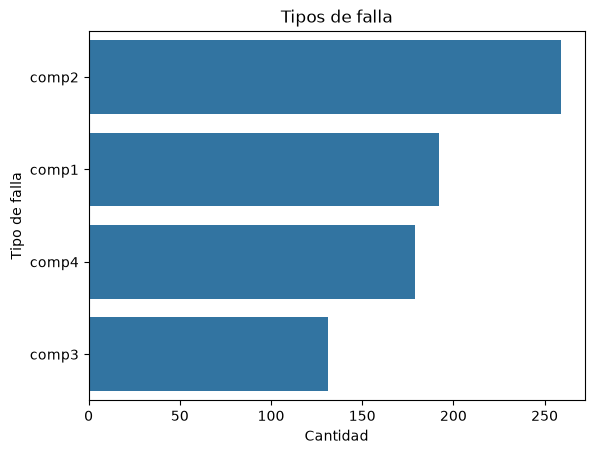

In [71]:
# Graficamos
sns.countplot(data=df_failures, y="failure", order=df_failures["failure"].value_counts().index)

plt.title("Tipos de falla")
plt.xlabel("Cantidad")
plt.ylabel("Tipo de falla")

plt.show()

## Análisis de mantenimientos

In [72]:
mantenimientos_totales = len(df_maint)
print(f"Total de eventos de mantenimiento registrados: {mantenimientos_totales:,}\n")

Total de eventos de mantenimiento registrados: 3,286



In [73]:
mantenimientos_por_comp = df_maint['comp'].value_counts()
print(mantenimientos_por_comp)

comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64


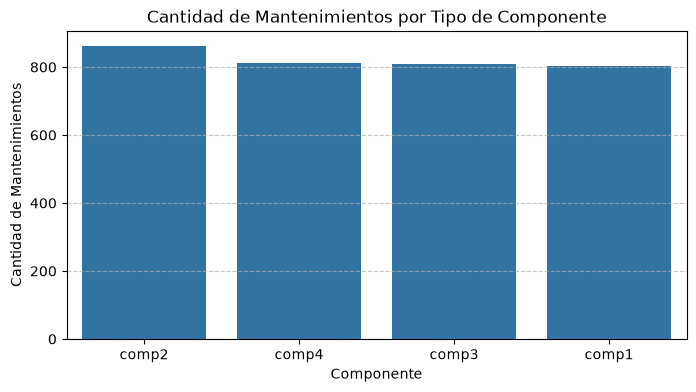

In [74]:
# Graficar la distribución por componente
plt.figure(figsize=(8, 4))
sns.countplot(data=df_maint, x='comp', order=mantenimientos_por_comp.index)
plt.title("Cantidad de Mantenimientos por Tipo de Componente")
plt.xlabel("Componente")
plt.ylabel("Cantidad de Mantenimientos")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [75]:
maint_machine = df_maint["machineID"].value_counts()

maint_machine.head(10)

machineID
66    39
68    39
70    39
10    38
14    38
24    38
27    38
42    38
84    38
1     37
Name: count, dtype: int64

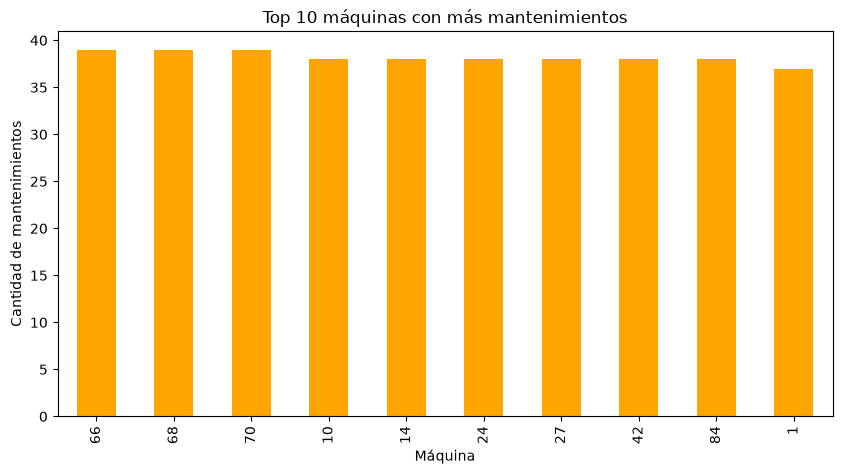

In [76]:
# Graficamos
maint_machine.head(10).plot(kind="bar", figsize=(10,5), color="orange")

plt.title("Top 10 máquinas con más mantenimientos")
plt.xlabel("Máquina")
plt.ylabel("Cantidad de mantenimientos")

plt.show()

## Análisis de sensores

In [77]:
df_telemetry.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [78]:
df_telemetry.describe()

,datetime,machineID,volt,rotate,pressure,vibration
count,876100,876100.000000,876100.000000,876100.000000,876100.000000,876100.000000
mean,2015-07-02 17:59:59.999999,50.500000,170.777736,446.605119,100.858668,40.385007
min,2015-01-01 06:00:00,1.000000,97.333604,138.432075,51.237106,14.877054
25%,2015-04-02 12:00:00,25.750000,160.304927,412.305714,93.498181,36.777299
50%,2015-07-02 18:00:00,50.500000,170.607338,447.558150,100.425559,40.237247
75%,2015-10-02 00:00:00,75.250000,181.004493,482.176600,107.555231,43.784938
max,2016-01-01 06:00:00,100.000000,255.124717,695.020984,185.951998,76.791072
std,NaN,28.866087,15.509114,52.673886,11.048679,5.370361


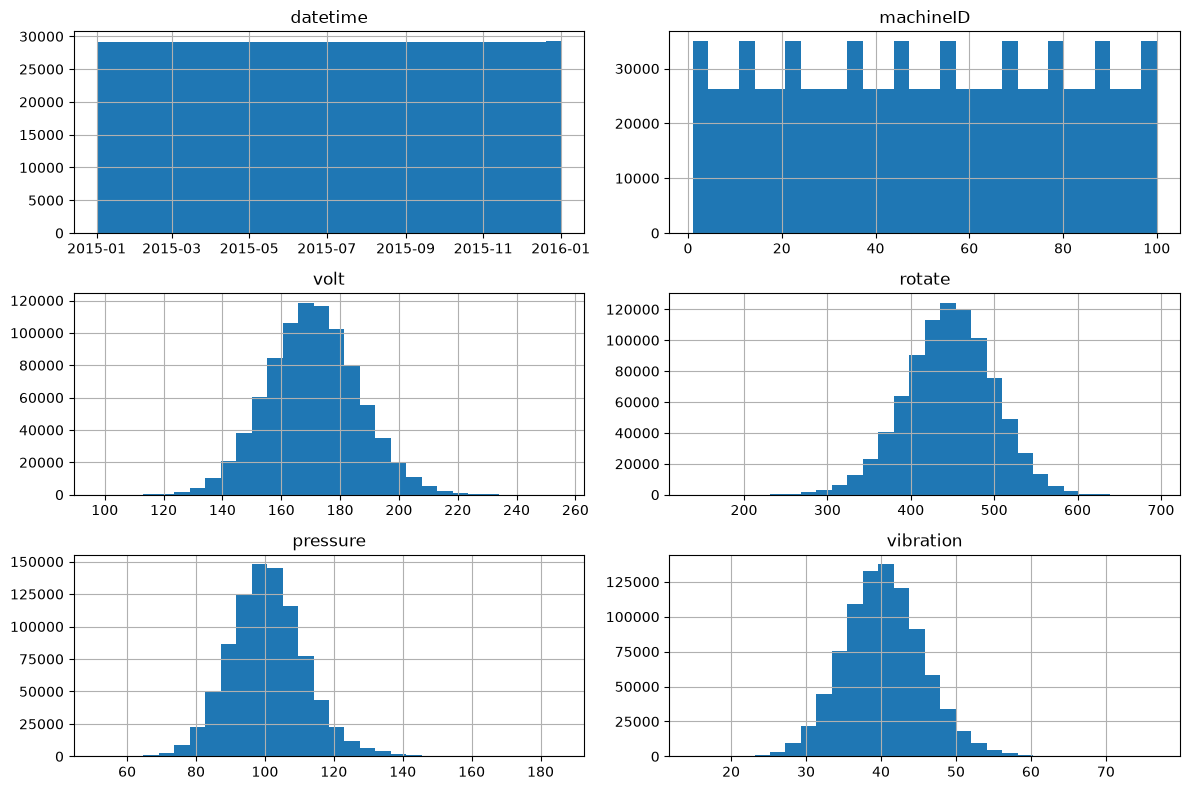

In [79]:
# Graficamos
df_telemetry.hist(figsize=(12,8), bins=30)

plt.tight_layout()
plt.show()

In [80]:
# Ordenado por tiempo

df_telemetry_sorted = df_telemetry.sort_values('datetime')
df_failures_sorted = df_failures.sort_values('datetime')

# Estado de los sensores en el instante exacto inmediatamente previo a la falla

telemetria_al_fallar = pd.merge_asof(
    df_failures_sorted,
    df_telemetry_sorted,
    on='datetime',
    by='machineID',
    direction='backward'
)

print("REGISTRO EXACTO DE SENSORES AL MOMENTO DE CADA FALLA")
print(telemetria_al_fallar[['datetime', 'machineID', 'failure', 'volt', 'rotate', 'pressure', 'vibration']].head(10))

REGISTRO EXACTO DE SENSORES AL MOMENTO DE CADA FALLA
             datetime  machineID failure        volt      rotate    pressure  \
0 2015-01-02 03:00:00         56   comp3  209.881920  456.998211  121.198938   
1 2015-01-02 03:00:00         99   comp3  173.235663  453.152821  129.723362   
2 2015-01-02 03:00:00         83   comp4  186.639092  468.764381   93.068489   
3 2015-01-02 03:00:00         59   comp1  169.206648  519.137970   86.805497   
4 2015-01-02 03:00:00         16   comp1  170.524081  405.302970  109.855730   
5 2015-01-02 03:00:00         16   comp3  170.524081  405.302970  109.855730   
6 2015-01-02 03:00:00         58   comp2  167.187100  331.460659  106.277021   
7 2015-01-02 03:00:00         17   comp4  158.098828  406.325391   97.001765   
8 2015-01-02 03:00:00         80   comp2  166.557579  419.798170   80.990671   
9 2015-01-02 03:00:00         73   comp2  160.627896  393.584972  131.324463   

   vibration  
0  36.340331  
1  44.624581  
2  46.737446  
3  42.

In [81]:
telemetria_promedio_maquina = telemetria_al_fallar.groupby(['machineID', 'failure'])[['volt', 'rotate', 'pressure', 'vibration']].mean().reset_index()

print("PROMEDIO EN INSTANTE EXACTO DE FALLA (POR MÁQUINA Y COMPONENTE)")
print(telemetria_promedio_maquina.head(10))
print("\n" + "-"*80 + "\n")

PROMEDIO EN INSTANTE EXACTO DE FALLA (POR MÁQUINA Y COMPONENTE)
   machineID failure        volt      rotate    pressure  vibration
0          1   comp1  198.257975  456.862342   89.333995  38.671900
1          1   comp2  179.186614  365.038868   92.682586  41.215736
2          1   comp4  162.193239  475.983481  108.111350  52.940566
3          2   comp1  179.277874  322.388170  118.153934  47.415885
4          2   comp2  176.196845  340.025092  104.793926  48.560217
5          3   comp1  171.461890  431.490019  110.075130  40.397341
6          3   comp2  167.226156  336.610011  104.094165  40.711785
7          4   comp1  210.059257  487.317242   93.990445  32.687573
8          4   comp2  169.762462  331.839063   92.859595  37.725685
9          5   comp1  205.943539  429.841928  100.360275  44.512207

--------------------------------------------------------------------------------



In [82]:
# Promedio de los sensores 24 horas previo a cada falla

promedios_pre_falla = []

for idx, row in df_failures.iterrows():
    m_id = row['machineID']
    fecha_falla = row['datetime']
    tipo_falla = row['failure']
    
    # Definir ventana de 24 horas hacia atrás
    inicio_ventana = fecha_falla - pd.Timedelta(hours=24)
    
    # Filtrar telemetría en dicha ventana
    sub_telem = df_telemetry[
        (df_telemetry['machineID'] == m_id) & 
        (df_telemetry['datetime'] >= inicio_ventana) & 
        (df_telemetry['datetime'] <= fecha_falla)
    ]
    
    if not sub_telem.empty:
        promedios = sub_telem[['volt', 'rotate', 'pressure', 'vibration']].mean().to_dict()
        promedios['machineID'] = m_id
        promedios['fecha_falla'] = fecha_falla
        promedios['componente_fallado'] = tipo_falla
        promedios_pre_falla.append(promedios)

df_promedios_ventana = pd.DataFrame(promedios_pre_falla)

print("PROMEDIO DE SENSORES EN VENTANA DE 24 HORAS PREVIAS A FALLA")
print(df_promedios_ventana[['fecha_falla', 'machineID', 'componente_fallado', 'volt', 'rotate', 'pressure', 'vibration']].head(10))

PROMEDIO DE SENSORES EN VENTANA DE 24 HORAS PREVIAS A FALLA
          fecha_falla  machineID componente_fallado        volt      rotate  \
0 2015-01-05 06:00:00          1              comp4  171.652345  443.649577   
1 2015-03-06 06:00:00          1              comp1  186.073202  441.668935   
2 2015-04-20 06:00:00          1              comp2  170.693832  373.755312   
3 2015-06-19 06:00:00          1              comp4  170.951946  461.142749   
4 2015-09-02 06:00:00          1              comp4  166.185130  441.775295   
5 2015-10-17 06:00:00          1              comp2  173.158389  375.585382   
6 2015-12-16 06:00:00          1              comp4  174.238329  443.555685   
7 2015-03-19 06:00:00          2              comp1  190.428502  368.632821   
8 2015-03-19 06:00:00          2              comp2  190.428502  368.632821   
9 2015-04-18 06:00:00          2              comp2  170.514494  360.848476   

     pressure  vibration  
0   98.636951  51.638785  
1   98.403798  3

In [83]:
promedio_24horas_maquina = df_promedios_ventana.groupby(['machineID', 'componente_fallado'])[['volt', 'rotate', 'pressure', 'vibration']].mean().reset_index()

print("PROMEDIO DE VENTANA DE 24H (POR MÁQUINA Y COMPONENTE)")
print(promedio_24horas_maquina.head(10))

PROMEDIO DE VENTANA DE 24H (POR MÁQUINA Y COMPONENTE)
   machineID componente_fallado        volt      rotate    pressure  vibration
0          1              comp1  186.073202  441.668935   98.403798  39.899448
1          1              comp2  171.926111  374.670347   98.498574  39.805982
2          1              comp4  170.756938  447.530826   99.256163  51.737056
3          2              comp1  190.428502  368.632821   99.505071  39.512276
4          2              comp2  177.171351  367.079108   99.229700  43.097617
5          3              comp1  190.836232  448.393814   99.707481  41.449021
6          3              comp2  169.551521  370.393396  101.583716  39.903232
7          4              comp1  191.290830  452.767888  100.863374  39.662158
8          4              comp2  167.928467  361.464066   98.573169  39.108131
9          5              comp1  189.109411  422.719612   99.378090  40.635101


## Correlación de sensores

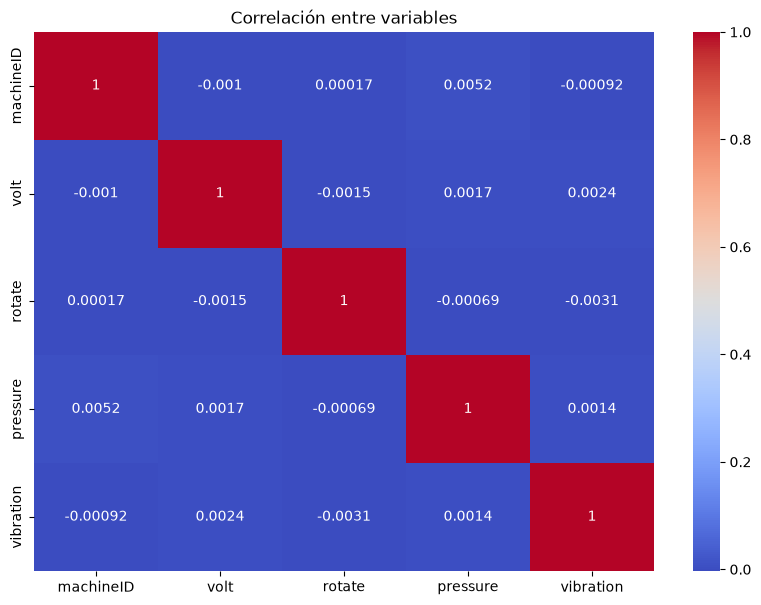

In [90]:
plt.figure(figsize=(10,7))

sns.heatmap(df_telemetry.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlación entre variables")

plt.show()

## Relación de errores y fallas

In [91]:
errores = df_errors.groupby("machineID").size()

fallas = df_failures.groupby("machineID").size()

In [92]:
df_resumen = pd.DataFrame({"errores": errores, "fallas": fallas}).fillna(0)

df_resumen.head()

,errores,fallas
machineID,,
1,35,7.0
2,28,4.0
3,39,5.0
4,31,6.0
5,38,7.0


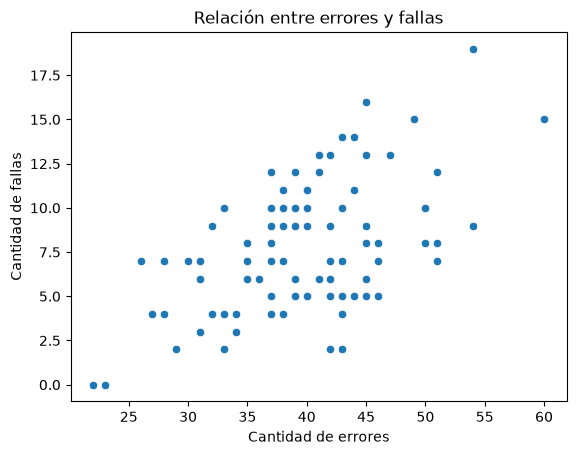

In [93]:
# Graficamos
sns.scatterplot(data=df_resumen, x="errores", y="fallas")

plt.title("Relación entre errores y fallas")
plt.xlabel("Cantidad de errores")
plt.ylabel("Cantidad de fallas")

plt.show()

In [94]:
# Valor numérico de la correlación de Pearson
correlacion_num = df_resumen["errores"].corr(df_resumen["fallas"])
print(f"Coeficiente de correlación entre errores y fallas: {correlacion_num:.4f}\n")

Coeficiente de correlación entre errores y fallas: 0.5378



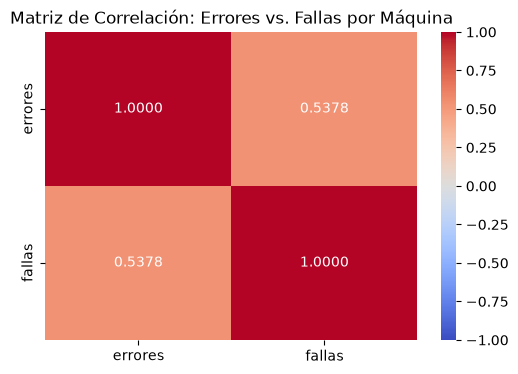

In [95]:
# Visualización mediante Mapa de Calor (Heatmap)
plt.figure(figsize=(6, 4))
sns.heatmap(df_resumen.corr(), annot=True, fmt=".4f", cmap="coolwarm", vmin=-1, vmax=1, cbar=True)
plt.title("Matriz de Correlación: Errores vs. Fallas por Máquina")
plt.show()